In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/raw/sales.csv")

In [ ]:
df.head()

,date,product_id,product_name,category,price,discount,promotion,day_of_week,month,is_weekend,units_sold
0,2024-01-01,P001,Wireless Headphones,Electronics,1999.0,0,0,0,1,False,33
1,2024-01-02,P001,Wireless Headphones,Electronics,1999.0,0,0,1,1,False,39
2,2024-01-03,P001,Wireless Headphones,Electronics,1999.0,0,0,2,1,False,39
3,2024-01-04,P001,Wireless Headphones,Electronics,1799.1,10,1,3,1,False,59
4,2024-01-05,P001,Wireless Headphones,Electronics,1999.0,0,0,4,1,False,35


In [5]:
df.shape

(3655, 11)

In [6]:
df.columns

Index(['date', 'product_id', 'product_name', 'category', 'price', 'discount',
       'promotion', 'day_of_week', 'month', 'is_weekend', 'units_sold'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          3655 non-null   str    
 1   product_id    3655 non-null   str    
 2   product_name  3655 non-null   str    
 3   category      3655 non-null   str    
 4   price         3655 non-null   float64
 5   discount      3655 non-null   int64  
 6   promotion     3655 non-null   int64  
 7   day_of_week   3655 non-null   int64  
 8   month         3655 non-null   int64  
 9   is_weekend    3655 non-null   bool   
 10  units_sold    3655 non-null   int64  
dtypes: bool(1), float64(1), int64(5), str(4)
memory usage: 289.2 KB


In [8]:
df["date"] = pd.to_datetime(df["date"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3655 entries, 0 to 3654
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          3655 non-null   datetime64[us]
 1   product_id    3655 non-null   str           
 2   product_name  3655 non-null   str           
 3   category      3655 non-null   str           
 4   price         3655 non-null   float64       
 5   discount      3655 non-null   int64         
 6   promotion     3655 non-null   int64         
 7   day_of_week   3655 non-null   int64         
 8   month         3655 non-null   int64         
 9   is_weekend    3655 non-null   bool          
 10  units_sold    3655 non-null   int64         
dtypes: bool(1), datetime64[us](1), float64(1), int64(5), str(3)
memory usage: 289.2 KB


In [10]:
df.isnull().sum()

date            0
product_id      0
product_name    0
category        0
price           0
discount        0
promotion       0
day_of_week     0
month           0
is_weekend      0
units_sold      0
dtype: int64

In [11]:
df.describe()

,date,price,discount,promotion,day_of_week,month,units_sold
count,3655,3655.000000,3655.000000,3655.000000,3655.000000,3655.000000,3655.000000
mean,2024-12-31 00:00:00,1887.947196,5.526676,0.340356,2.991792,6.519836,38.059918
min,2024-01-01 00:00:00,799.200000,0.000000,0.000000,0.000000,1.000000,12.000000
25%,2024-07-01 00:00:00,1349.100000,0.000000,0.000000,1.000000,4.000000,27.000000
50%,2024-12-31 00:00:00,1899.050000,0.000000,0.000000,3.000000,7.000000,36.000000
75%,2025-07-02 00:00:00,2499.000000,10.000000,1.000000,5.000000,10.000000,46.000000
max,2025-12-31 00:00:00,2999.000000,20.000000,1.000000,6.000000,12.000000,116.000000
std,NaN,682.374279,6.733271,0.473894,2.000941,3.450023,14.283852


In [12]:
df.groupby("product_name")["units_sold"].mean().sort_values(ascending=False)

product_name
Yoga Mat               50.143639
Wireless Headphones    45.006840
Smart Watch            38.191518
Running Shoes          31.746922
Travel Backpack        25.210670
Name: units_sold, dtype: float64

In [13]:
df.groupby("product_name")["units_sold"].sum().sort_values(ascending=False)

product_name
Yoga Mat               36655
Wireless Headphones    32900
Smart Watch            27918
Running Shoes          23207
Travel Backpack        18429
Name: units_sold, dtype: int64

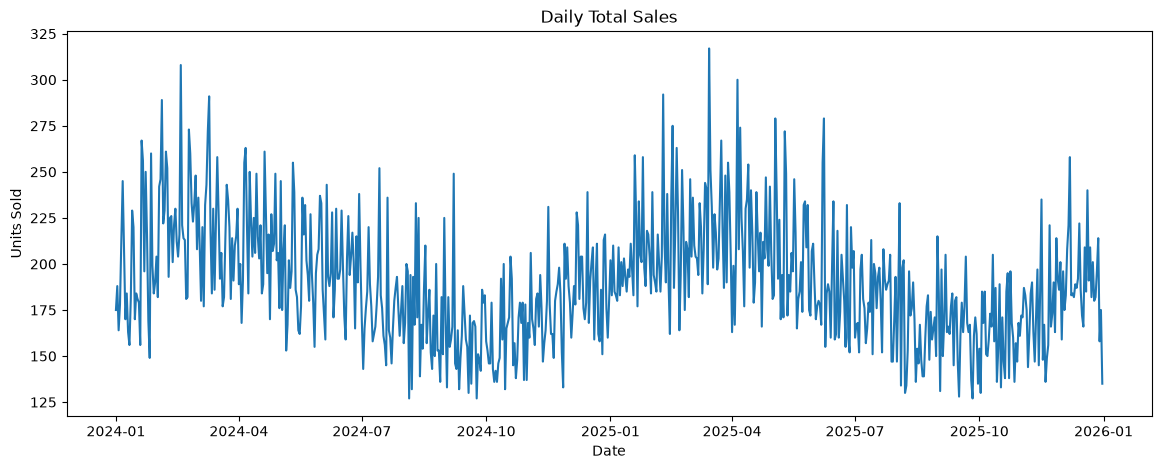

In [15]:
daily_sales = (
    df.groupby("date")["units_sold"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales.index,
    daily_sales.values
)

plt.title("Daily Total Sales")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.show()

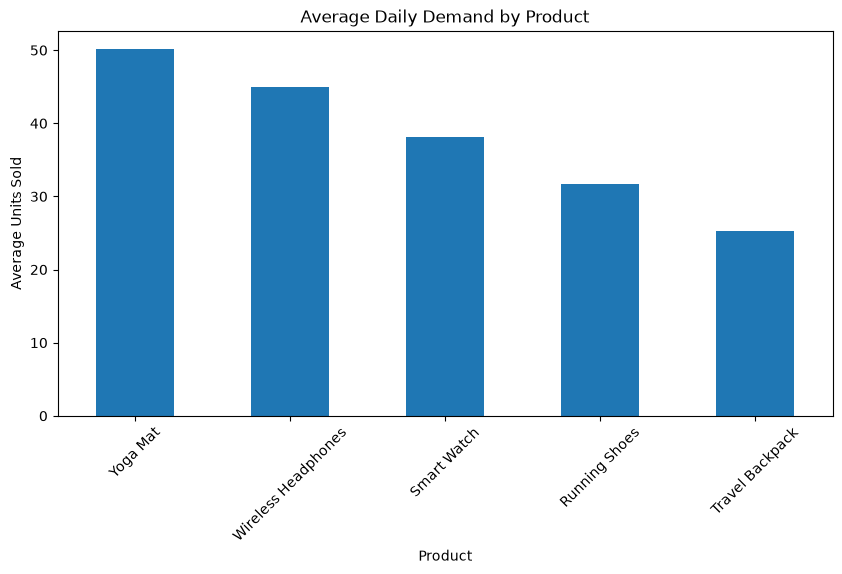

In [16]:
product_demand = (
    df.groupby("product_name")["units_sold"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

product_demand.plot(kind="bar")

plt.title("Average Daily Demand by Product")
plt.xlabel("Product")
plt.ylabel("Average Units Sold")

plt.xticks(rotation=45)

plt.show()

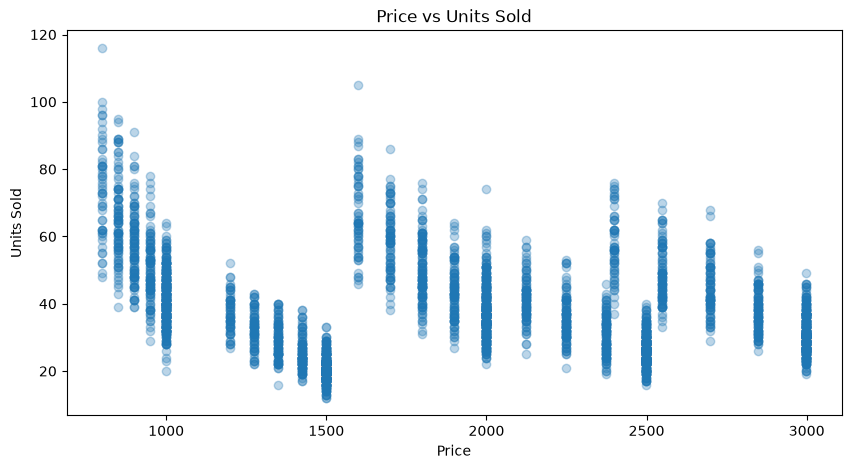

In [17]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["price"],
    df["units_sold"],
    alpha=0.3
)

plt.title("Price vs Units Sold")
plt.xlabel("Price")
plt.ylabel("Units Sold")

plt.show()

In [18]:
discount_demand = (
    df.groupby("discount")["units_sold"]
    .mean()
)

print(discount_demand)

discount
0     31.318989
5     36.862319
10    43.726236
15    49.759174
20    56.184397
Name: units_sold, dtype: float64


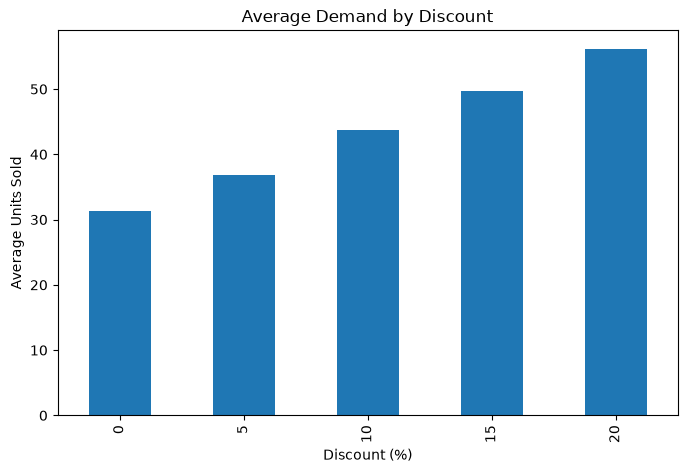

In [19]:
plt.figure(figsize=(8, 5))

discount_demand.plot(kind="bar")

plt.title("Average Demand by Discount")
plt.xlabel("Discount (%)")
plt.ylabel("Average Units Sold")

plt.show()

In [20]:
weekend_demand = (
    df.groupby("is_weekend")["units_sold"]
    .mean()
)

print(weekend_demand)

is_weekend
False    36.416444
True     42.192308
Name: units_sold, dtype: float64


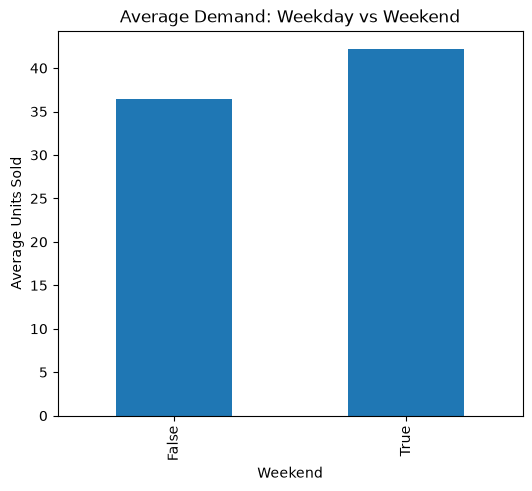

In [21]:
plt.figure(figsize=(6, 5))

weekend_demand.plot(kind="bar")

plt.title("Average Demand: Weekday vs Weekend")
plt.xlabel("Weekend")
plt.ylabel("Average Units Sold")

plt.show()

In [22]:
monthly_demand = (
    df.groupby("month")["units_sold"]
    .mean()
)

print(monthly_demand)

month
1     39.793548
2     44.038596
3     43.883871
4     42.790000
5     40.332258
6     38.836667
7     35.648387
8     33.883871
9     32.616667
10    32.270968
11    35.213333
12    37.803226
Name: units_sold, dtype: float64


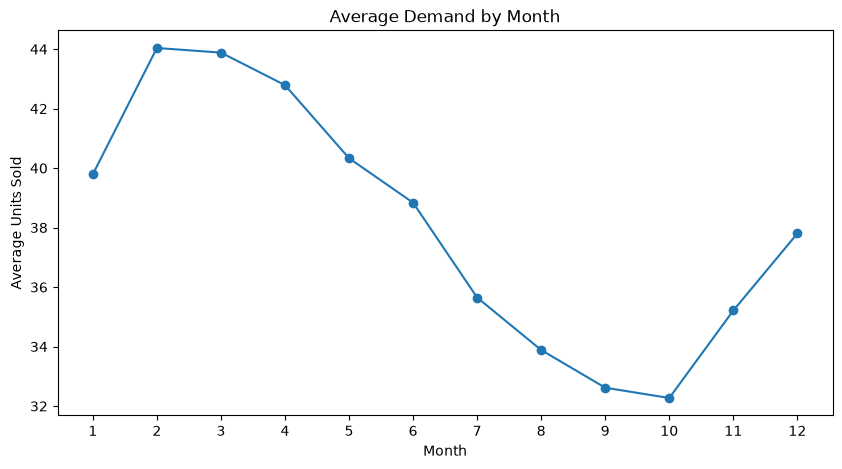

In [23]:
plt.figure(figsize=(10, 5))

monthly_demand.plot(kind="line", marker="o")

plt.title("Average Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")

plt.xticks(range(1, 13))

plt.show()

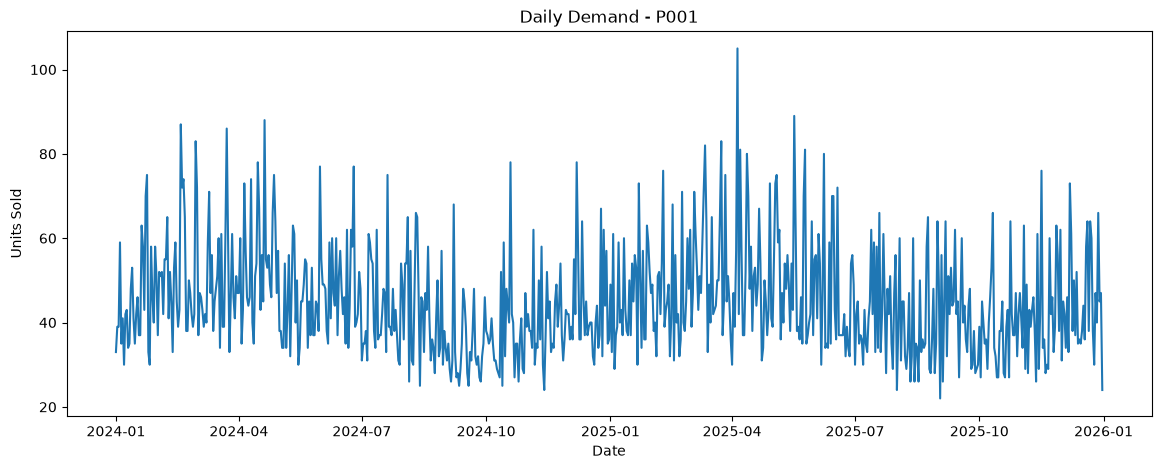

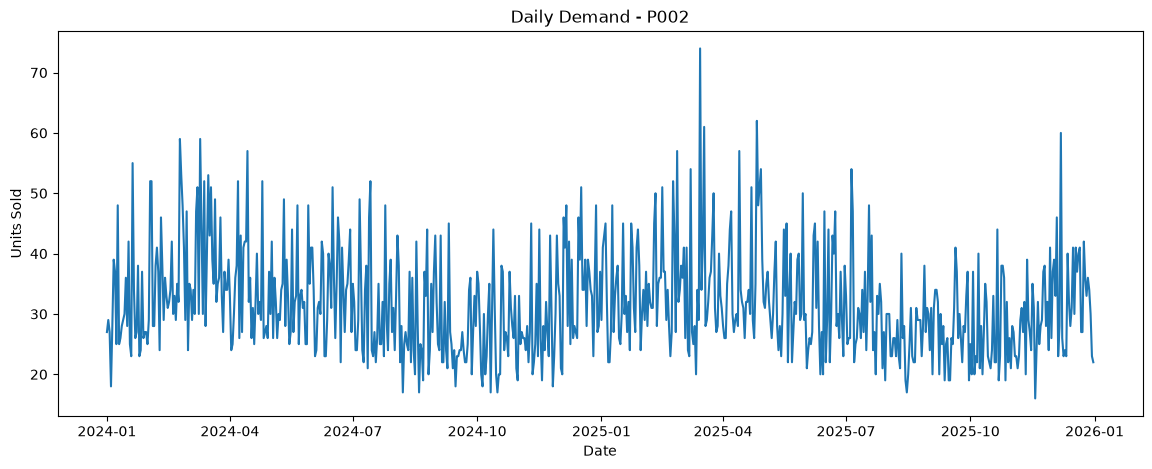

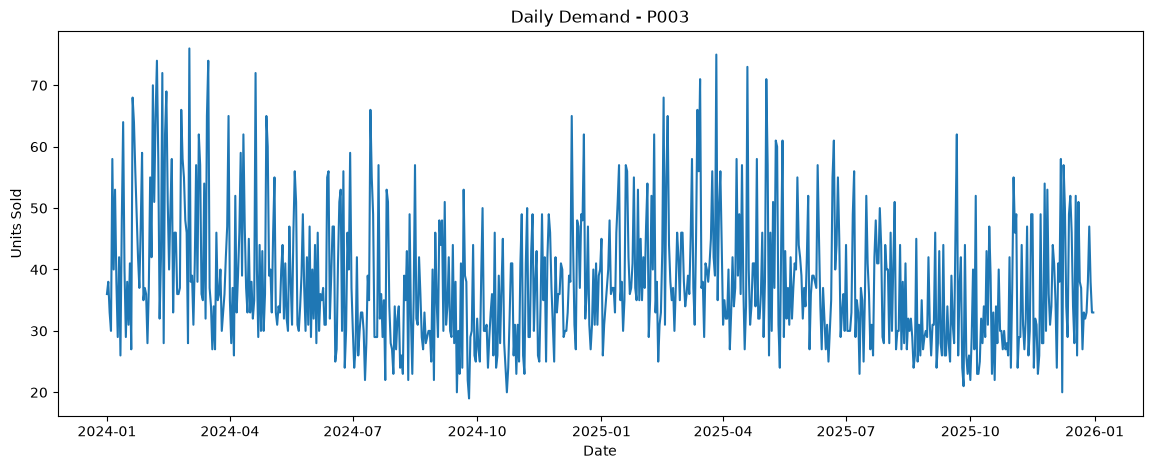

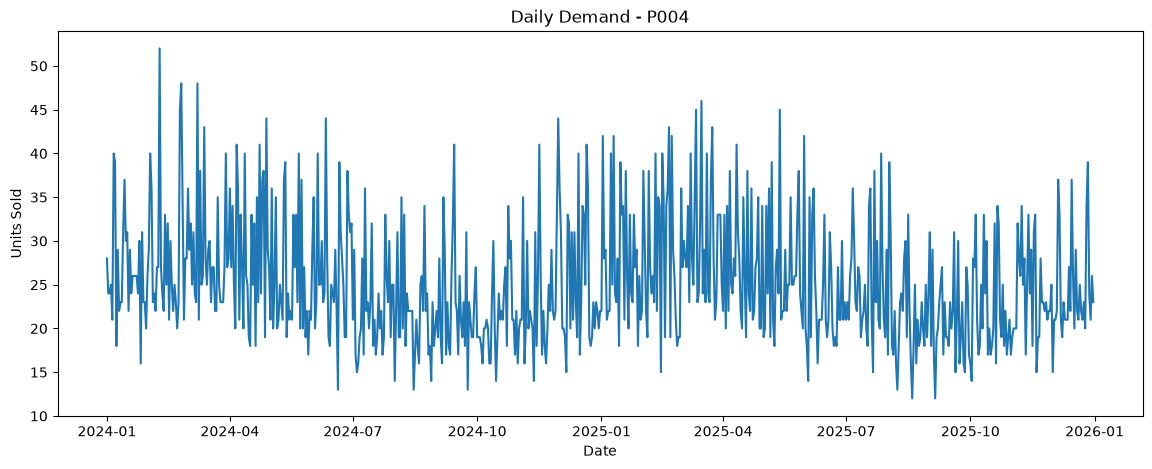

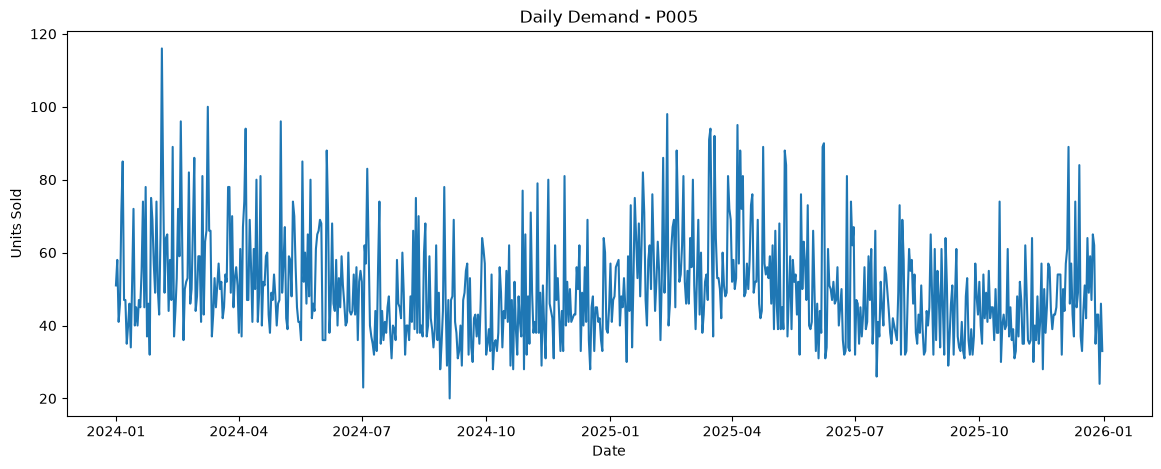

In [24]:
import matplotlib.pyplot as plt

for product_id in df["product_id"].unique():

    product_data = df[df["product_id"] == product_id]

    plt.figure(figsize=(14, 5))

    plt.plot(
        product_data["date"],
        product_data["units_sold"]
    )

    plt.title(f"Daily Demand - {product_id}")
    plt.xlabel("Date")
    plt.ylabel("Units Sold")

    plt.show()

In [26]:
df = df.sort_values(
    ["product_id", "date"]
).reset_index(drop=True)

df.head()

,date,product_id,product_name,category,price,discount,promotion,day_of_week,month,is_weekend,units_sold
0,2024-01-01,P001,Wireless Headphones,Electronics,1999.0,0,0,0,1,False,33
1,2024-01-02,P001,Wireless Headphones,Electronics,1999.0,0,0,1,1,False,39
2,2024-01-03,P001,Wireless Headphones,Electronics,1999.0,0,0,2,1,False,39
3,2024-01-04,P001,Wireless Headphones,Electronics,1799.1,10,1,3,1,False,59
4,2024-01-05,P001,Wireless Headphones,Electronics,1999.0,0,0,4,1,False,35


In [27]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

In [28]:
df["lag_1"] = (
    df.groupby("product_id")["units_sold"]
    .shift(1)
)

df["lag_7"] = (
    df.groupby("product_id")["units_sold"]
    .shift(7)
)

df["lag_14"] = (
    df.groupby("product_id")["units_sold"]
    .shift(14)
)

df["lag_28"] = (
    df.groupby("product_id")["units_sold"]
    .shift(28)
)

df["rolling_mean_7"] = (
    df.groupby("product_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["rolling_mean_14"] = (
    df.groupby("product_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

df["rolling_mean_28"] = (
    df.groupby("product_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(28).mean())
)

df["rolling_std_7"] = (
    df.groupby("product_id")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

In [29]:
print(df["lag_14"])

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
3650    49.0
3651    84.0
3652    37.0
3653    33.0
3654    44.0
Name: lag_14, Length: 3655, dtype: float64


In [31]:
# ==========================================
# TRAIN / VALIDATION / TEST SPLIT
# ==========================================

In [32]:

train = df[
    df["date"] < "2025-07-01"
].copy()

validation = df[
    (df["date"] >= "2025-07-01")
    & (df["date"] < "2025-10-01")
].copy()

test = df[
    df["date"] >= "2025-10-01"
].copy()

In [33]:
print("Train:", train.shape)
print("Validation:", validation.shape)
print("Test:", test.shape)

Train: (2735, 22)
Validation: (460, 22)
Test: (460, 22)


In [34]:
print(
    "Train:",
    train["date"].min(),
    "to",
    train["date"].max()
)

print(
    "Validation:",
    validation["date"].min(),
    "to",
    validation["date"].max()
)

print(
    "Test:",
    test["date"].min(),
    "to",
    test["date"].max()
)

Train: 2024-01-01 00:00:00 to 2025-06-30 00:00:00
Validation: 2025-07-01 00:00:00 to 2025-09-30 00:00:00
Test: 2025-10-01 00:00:00 to 2025-12-31 00:00:00


In [35]:
baseline = df[
    ["date", "product_id", "units_sold"]
].copy()

baseline = baseline.sort_values(
    ["product_id", "date"]
)

baseline["prediction"] = (
    baseline
    .groupby("product_id")["units_sold"]
    .shift(1)
)

In [36]:
baseline.head(10)

,date,product_id,units_sold,prediction
0,2024-01-01,P001,33,NaN
1,2024-01-02,P001,39,33.0
2,2024-01-03,P001,39,39.0
3,2024-01-04,P001,59,39.0
4,2024-01-05,P001,35,59.0
5,2024-01-06,P001,41,35.0
6,2024-01-07,P001,30,41.0
7,2024-01-08,P001,42,30.0
8,2024-01-09,P001,43,42.0
9,2024-01-10,P001,34,43.0


In [37]:
baseline_test = baseline[
    baseline["date"] >= "2025-10-01"
].dropna()

In [38]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    baseline_test["units_sold"],
    baseline_test["prediction"]
)

print(
    f"Naive Baseline MAE: {baseline_mae:.2f}"
)

Naive Baseline MAE: 10.10


Random Forest 

In [39]:
features = [
    "price",
    "discount",
    "promotion",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28",
    "rolling_std_7",
]

In [40]:
X_train = train[features]
y_train = train["units_sold"]

X_validation = validation[features]
y_validation = validation["units_sold"]

X_test = test[features]
y_test = test["units_sold"]

In [41]:
X_train.isna().sum()

price                0
discount             0
promotion            0
day_of_week          0
month                0
is_weekend           0
lag_1                5
lag_7               35
lag_14              70
lag_28             140
rolling_mean_7      35
rolling_mean_14     70
rolling_mean_28    140
rolling_std_7       35
dtype: int64

In [42]:
train_ml = train.dropna(subset=features).copy()
validation_ml = validation.dropna(subset=features).copy()
test_ml = test.dropna(subset=features).copy()

In [43]:
X_train = train_ml[features]
y_train = train_ml["units_sold"]

X_validation = validation_ml[features]
y_validation = validation_ml["units_sold"]

X_test = test_ml[features]
y_test = test_ml["units_sold"]

In [44]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [45]:
from sklearn.ensemble import RandomForestRegressor

In [46]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [47]:
model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [48]:
validation_predictions = model.predict(
    X_validation
)

In [49]:
validation_mae = mean_absolute_error(
    y_validation,
    validation_predictions
)

print(
    f"Validation MAE: {validation_mae:.2f}"
)

Validation MAE: 3.94


Seasonal Naive 


In [50]:
print(train_ml[["date", "product_id", "units_sold"]].head(10))

print(validation_ml[["date", "product_id", "units_sold"]].head(10))

         date product_id  units_sold
28 2024-01-29       P001          40
29 2024-01-30       P001          58
30 2024-01-31       P001          51
31 2024-02-01       P001          37
32 2024-02-02       P001          52
33 2024-02-03       P001          51
34 2024-02-04       P001          52
35 2024-02-05       P001          42
36 2024-02-06       P001          55
37 2024-02-07       P001          55
          date product_id  units_sold
547 2025-07-01       P001          30
548 2025-07-02       P001          42
549 2025-07-03       P001          45
550 2025-07-04       P001          35
551 2025-07-05       P001          37
552 2025-07-06       P001          36
553 2025-07-07       P001          30
554 2025-07-08       P001          43
555 2025-07-09       P001          35
556 2025-07-10       P001          33


In [51]:
print(train_ml["date"].min(), train_ml["date"].max())
print(validation_ml["date"].min(), validation_ml["date"].max())


2024-01-29 00:00:00 2025-06-30 00:00:00
2025-07-01 00:00:00 2025-09-30 00:00:00


In [52]:
print(train_ml["date"].min(), train_ml["date"].max())
print(validation_ml["date"].min(), validation_ml["date"].max())

2024-01-29 00:00:00 2025-06-30 00:00:00
2025-07-01 00:00:00 2025-09-30 00:00:00


In [53]:
historical_data = pd.concat(
    [train_ml, validation_ml]
).sort_values(
    ["product_id", "date"]
)

In [54]:
historical_data["seasonal_naive_prediction"] = (
    historical_data
    .groupby("product_id")["units_sold"]
    .shift(7)
)

In [55]:
seasonal_validation = historical_data[
    historical_data["date"].isin(validation_ml["date"])
]

In [56]:
seasonal_predictions = seasonal_validation[
    "seasonal_naive_prediction"
]

In [57]:
seasonal_actual = seasonal_validation[
    "units_sold"
]

In [ ]:
seasonal_mae = mean_absolute_error(
    seasonal_actual,
    seasonal_predictions
)

print(f"Seasonal Naive MAE: {seasonal_mae:.2f}")

Seasonal Naive MAE: 9.49


In [59]:
print(
    historical_data[
        ["date", "product_id", "units_sold", "seasonal_naive_prediction"]
    ].tail(15)
)

           date product_id  units_sold  seasonal_naive_prediction
3548 2025-09-16       P005          34                       37.0
3549 2025-09-17       P005          33                       46.0
3550 2025-09-18       P005          41                       51.0
3551 2025-09-19       P005          33                       32.0
3552 2025-09-20       P005          31                       48.0
3553 2025-09-21       P005          48                       61.0
3554 2025-09-22       P005          53                       37.0
3555 2025-09-23       P005          36                       34.0
3556 2025-09-24       P005          32                       33.0
3557 2025-09-25       P005          39                       41.0
3558 2025-09-26       P005          32                       33.0
3559 2025-09-27       P005          37                       31.0
3560 2025-09-28       P005          57                       48.0
3561 2025-09-29       P005          48                       53.0
3562 2025-

Moving Average 


In [60]:
historical_data["moving_average_prediction"] = (
    historical_data
    .groupby("product_id")["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

In [63]:
print(
    historical_data[
        ["date", "product_id", "units_sold", "moving_average_prediction"]
    ].tail(15)
)

           date product_id  units_sold  moving_average_prediction
3548 2025-09-16       P005          34                  44.571429
3549 2025-09-17       P005          33                  44.142857
3550 2025-09-18       P005          41                  42.285714
3551 2025-09-19       P005          33                  40.857143
3552 2025-09-20       P005          31                  41.000000
3553 2025-09-21       P005          48                  38.571429
3554 2025-09-22       P005          53                  36.714286
3555 2025-09-23       P005          36                  39.000000
3556 2025-09-24       P005          32                  39.285714
3557 2025-09-25       P005          39                  39.142857
3558 2025-09-26       P005          32                  38.857143
3559 2025-09-27       P005          37                  38.714286
3560 2025-09-28       P005          57                  39.571429
3561 2025-09-29       P005          48                  40.857143
3562 2025-

In [66]:
seasonal_validation = historical_data[
    historical_data["date"].isin(validation_ml["date"])
]

In [71]:
seasonal_validation.info()

<class 'pandas.DataFrame'>
Index: 460 entries, 547 to 3562
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       460 non-null    datetime64[us]
 1   product_id                 460 non-null    str           
 2   product_name               460 non-null    str           
 3   category                   460 non-null    str           
 4   price                      460 non-null    float64       
 5   discount                   460 non-null    int64         
 6   promotion                  460 non-null    int64         
 7   day_of_week                460 non-null    int32         
 8   month                      460 non-null    int32         
 9   is_weekend                 460 non-null    int64         
 10  units_sold                 460 non-null    int64         
 11  year                       460 non-null    int32         
 12  day                  

In [72]:
moving_average_mae = mean_absolute_error(
    seasonal_validation["units_sold"],
    seasonal_validation["moving_average_prediction"]
)

print(f"Moving Average MAE: {moving_average_mae:.2f}")

Moving Average MAE: 7.35


Linear Regeression 


In [73]:
from sklearn.linear_model import LinearRegression


linear_model = LinearRegression()

In [74]:
linear_model.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[-0. , 1.33,-0.89,..., 0.18, 0.79,-0.18]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](14,)","['price','discount','promotion',...,'rolling_mean_14','rolling_mean_28', 'rolling_std_7']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.393
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)


In [75]:
linear_predictions = linear_model.predict(
    X_validation
)

In [76]:
linear_mae = mean_absolute_error(
    y_validation,
    linear_predictions
)

print(f"Linear Regression MAE: {linear_mae:.2f}")

Linear Regression MAE: 4.20


Gradient Boosting


In [77]:
from sklearn.ensemble import GradientBoostingRegressor

In [ ]:
gradient_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [ ]:
gradient_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [80]:
gradient_predictions = gradient_model.predict(
    X_validation
)

In [81]:
gradient_mae = mean_absolute_error(
    y_validation,
    gradient_predictions
)

print(f"Gradient Boosting MAE: {gradient_mae:.2f}")

Gradient Boosting MAE: 3.67


XGBoost

In [82]:
import xgboost

print(xgboost.__version__)

3.4.1


In [83]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)

In [84]:
xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [85]:
xgb_predictions = xgb_model.predict(
    X_validation
)

In [86]:
xgb_mae = mean_absolute_error(
    y_validation,
    xgb_predictions
)

print(f"XGBoost MAE: {xgb_mae:.2f}")

XGBoost MAE: 3.65


Time series cross validation 

In [89]:
from sklearn.model_selection import TimeSeriesSplit


In [90]:
tscv = TimeSeriesSplit(n_splits=4)

for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_train),
    start=1
):
    print(f"Fold {fold}")
    print("Training:", train_index[0], "→", train_index[-1])
    print("Validation:", validation_index[0], "→", validation_index[-1])
    print()

Fold 1
Training: 0 → 518
Validation: 519 → 1037

Fold 2
Training: 0 → 1037
Validation: 1038 → 1556

Fold 3
Training: 0 → 1556
Validation: 1557 → 2075

Fold 4
Training: 0 → 2075
Validation: 2076 → 2594



In [96]:
train_ml = train_ml.sort_values(
    ["date", "product_id"]
).reset_index(drop=True)

In [97]:
X_train = train_ml[features]
y_train = train_ml["units_sold"]

In [98]:
tscv = TimeSeriesSplit(n_splits=4)

In [99]:
for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_train),
    start=1
):
    print(f"Fold {fold}")

    print(
        "Training:",
        train_ml.iloc[train_index]["date"].iloc[0],
        "→",
        train_ml.iloc[train_index]["date"].iloc[-1]
    )

    print(
        "Validation:",
        train_ml.iloc[validation_index]["date"].iloc[0],
        "→",
        train_ml.iloc[validation_index]["date"].iloc[-1]
    )

    print()

Fold 1
Training: 2024-01-29 00:00:00 → 2024-05-11 00:00:00
Validation: 2024-05-11 00:00:00 → 2024-08-23 00:00:00

Fold 2
Training: 2024-01-29 00:00:00 → 2024-08-23 00:00:00
Validation: 2024-08-23 00:00:00 → 2024-12-05 00:00:00

Fold 3
Training: 2024-01-29 00:00:00 → 2024-12-05 00:00:00
Validation: 2024-12-05 00:00:00 → 2025-03-19 00:00:00

Fold 4
Training: 2024-01-29 00:00:00 → 2025-03-19 00:00:00
Validation: 2025-03-19 00:00:00 → 2025-06-30 00:00:00



In [100]:
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

fold_maes = []

for fold, (train_index, validation_index) in enumerate(
    tscv.split(X_train),
    start=1
):

    X_fold_train = X_train.iloc[train_index]
    y_fold_train = y_train.iloc[train_index]

    X_fold_validation = X_train.iloc[validation_index]
    y_fold_validation = y_train.iloc[validation_index]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_fold_train,
        y_fold_train
    )

    predictions = model.predict(
        X_fold_validation
    )

    mae = mean_absolute_error(
        y_fold_validation,
        predictions
    )

    fold_maes.append(mae)

    print(f"Fold {fold} MAE: {mae:.2f}")

print(f"\nAverage CV MAE: {sum(fold_maes) / len(fold_maes):.2f}")

Fold 1 MAE: 5.20
Fold 2 MAE: 3.68
Fold 3 MAE: 4.72
Fold 4 MAE: 4.46

Average CV MAE: 4.51


In [101]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=4)

results = []

for n_estimators in [100, 200, 300]:

    for learning_rate in [0.03, 0.05, 0.1]:

        for max_depth in [2, 3, 4]:

            fold_maes = []

            for train_index, validation_index in tscv.split(X_train):

                X_fold_train = X_train.iloc[train_index]
                y_fold_train = y_train.iloc[train_index]

                X_fold_validation = X_train.iloc[validation_index]
                y_fold_validation = y_train.iloc[validation_index]

                model = XGBRegressor(
                    n_estimators=n_estimators,
                    learning_rate=learning_rate,
                    max_depth=max_depth,
                    random_state=42,
                    n_jobs=-1
                )

                model.fit(
                    X_fold_train,
                    y_fold_train
                )

                predictions = model.predict(
                    X_fold_validation
                )

                mae = mean_absolute_error(
                    y_fold_validation,
                    predictions
                )

                fold_maes.append(mae)

            average_mae = sum(fold_maes) / len(fold_maes)

            results.append({
                "n_estimators": n_estimators,
                "learning_rate": learning_rate,
                "max_depth": max_depth,
                "cv_mae": average_mae
            })

print("Tuning complete!")

Tuning complete!


In [102]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "cv_mae"
).reset_index(drop=True)

print(results_df)

    n_estimators  learning_rate  max_depth    cv_mae
0            200           0.05          2  4.488059
1            300           0.03          2  4.495578
2            300           0.05          2  4.495653
3            100           0.10          2  4.506107
4            300           0.03          3  4.512997
5            200           0.05          3  4.513877
6            200           0.03          3  4.519336
7            100           0.10          3  4.526137
8            100           0.05          3  4.543914
9            200           0.10          2  4.555561
10           300           0.05          3  4.555605
11           200           0.03          2  4.569616
12           200           0.03          4  4.579629
13           200           0.05          4  4.593056
14           300           0.03          4  4.597198
15           100           0.05          4  4.603944
16           200           0.10          3  4.623246
17           300           0.05          4  4.

In [103]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=42,
        n_jobs=-1
    )
}

cv_results = []

for model_name, model in models.items():

    fold_maes = []

    for train_index, validation_index in tscv.split(X_train):

        X_fold_train = X_train.iloc[train_index]
        y_fold_train = y_train.iloc[train_index]

        X_fold_validation = X_train.iloc[validation_index]
        y_fold_validation = y_train.iloc[validation_index]

        model.fit(
            X_fold_train,
            y_fold_train
        )

        predictions = model.predict(
            X_fold_validation
        )

        mae = mean_absolute_error(
            y_fold_validation,
            predictions
        )

        fold_maes.append(mae)

    average_mae = sum(fold_maes) / len(fold_maes)

    cv_results.append({
        "model": model_name,
        "cv_mae": average_mae
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "cv_mae"
).reset_index(drop=True)

print(cv_results_df)

               model    cv_mae
0            XGBoost  4.488059
1  Gradient Boosting  4.571241
2      Random Forest  4.692148


In [104]:
final_xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [105]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

print(feature_importance)

            feature  importance
0          discount    0.257716
1   rolling_mean_28    0.254769
2   rolling_mean_14    0.175561
3    rolling_mean_7    0.130206
4             price    0.055039
5       day_of_week    0.045159
6             lag_7    0.037050
7            lag_14    0.016441
8             month    0.012745
9             lag_1    0.005906
10           lag_28    0.005472
11    rolling_std_7    0.003936
12       is_weekend    0.000000
13        promotion    0.000000


Final testing 


In [106]:
X_final_train = pd.concat(
    [X_train, X_validation]
)

y_final_train = pd.concat(
    [y_train, y_validation]
)

In [107]:
final_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
    n_jobs=-1
)

In [108]:
final_model.fit(
    X_final_train,
    y_final_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [109]:
test_predictions = final_model.predict(
    X_test
)

In [110]:
test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

print(f"Final Test MAE: {test_mae:.2f}")

Final Test MAE: 3.68


Error analysis

In [111]:
test_results = test_ml[[
    "date",
    "product_id",
    "units_sold"
]].copy()

test_results["prediction"] = test_predictions

test_results["error"] = (
    test_results["units_sold"]
    - test_results["prediction"]
)

test_results["absolute_error"] = (
    test_results["error"].abs()
)

print(test_results.head(10))

          date product_id  units_sold  prediction      error  absolute_error
639 2025-10-01       P001          39   45.356434  -6.356434        6.356434
640 2025-10-02       P001          27   38.465065 -11.465065       11.465065
641 2025-10-03       P001          45   51.086365  -6.086365        6.086365
642 2025-10-04       P001          40   43.227623  -3.227623        3.227623
643 2025-10-05       P001          35   36.125446  -1.125446        1.125446
644 2025-10-06       P001          36   31.486355   4.513645        4.513645
645 2025-10-07       P001          29   38.995300  -9.995300        9.995300
646 2025-10-08       P001          40   37.202240   2.797760        2.797760
647 2025-10-09       P001          46   41.942005   4.057995        4.057995
648 2025-10-10       P001          53   53.471867  -0.471867        0.471867


In [ ]:
worst_predictions = test_results.sort_values(
    "absolute_error",
    ascending=False
)

print(worst_predictions.head(10))

           date product_id  units_sold  prediction      error  absolute_error
3637 2025-12-14       P005          84   61.811047  22.188953       22.188953
3629 2025-12-06       P005          89   67.162621  21.837379       21.837379
3652 2025-12-29       P005          24   40.935738 -16.935738       16.935738
2185 2025-12-24       P003          33   47.843716 -14.843716       14.843716
662  2025-10-24       P001          64   49.361115  14.638885       14.638885
672  2025-11-03       P001          63   49.588108  13.411892       13.411892
3641 2025-12-18       P005          51   64.215942 -13.215942       13.215942
685  2025-11-16       P001          76   62.961456  13.038544       13.038544
1437 2025-12-07       P002          60   47.071613  12.928387       12.928387
730  2025-12-31       P001          24   36.492268 -12.492268       12.492268


In [113]:
product_error = (
    test_results
    .groupby("product_id")["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

print(product_error)

product_id
P005    4.758361
P001    4.547421
P003    3.861725
P002    2.978732
P004    2.268127
Name: absolute_error, dtype: float64


In [114]:
average_error = (
    test_results
    .groupby("product_id")["error"]
    .mean()
    .sort_values()
)

print(average_error)

product_id
P002   -0.472225
P004   -0.334454
P001    0.222788
P005    0.353435
P003    0.391681
Name: error, dtype: float64
